plot of log mse vs eigenvalues in samples of both close to and far away from the local minimum 

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
import pickle
with open('../../results/benchmark_scan_multi/SOBOL_results_1.pkl', 'rb') as f: # X is 1,2,3 for different objectives 
    results_1, res_close, res_far = pickle.load(f) 

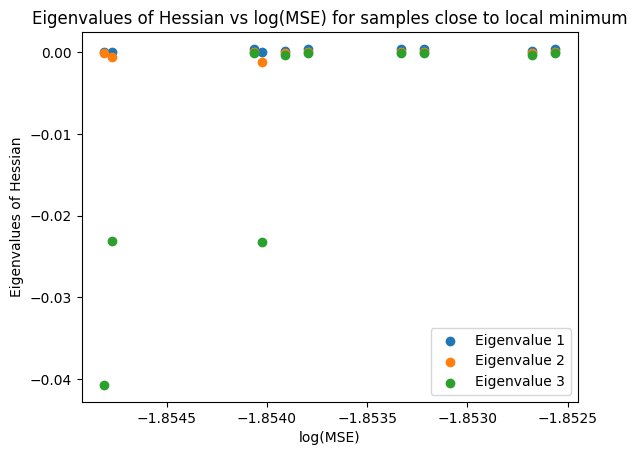

In [3]:
from SOBOL_scan import compute_weighted_MSE, compute_hessian_phi, compute_eig
log_mse_arr=[]
eigval_1_arr=[]
eigval_2_arr=[]
eigval_3_arr=[]
A_VARS = {
    1: ["I_1", "current", lambda x: x],
    3: ["I_3", "current", lambda x: x],
    10: ["I_10", "current", lambda x: x],
}
A_OBJ = {
    11: [{"measure": ["x", "dispersion"], "goal": 0.0, "weight": 1.0}]
}
for sub_sample in res_close:
    current=sub_sample["current"]
    I_dict={"I_1": current[0], "I_3": current[1], "I_10": current[2]}
    
    mse=compute_weighted_MSE(I_dict, A_VARS, A_OBJ)[0]
    log_mse_arr.append(np.log10(mse))
    H=compute_hessian_phi(I_dict, A_VARS, A_OBJ)[0]
    eigvals=compute_eig(H)[0]
    # print(eigvals)
    eigvals.sort()
    eigvals = eigvals[::-1]
    eigval_1_arr.append(eigvals[0])
    eigval_2_arr.append(eigvals[1])
    eigval_3_arr.append(eigvals[2])
plt.scatter(log_mse_arr, eigval_1_arr, label='Eigenvalue 1')
plt.scatter(log_mse_arr, eigval_2_arr, label='Eigenvalue 2')
plt.scatter(log_mse_arr, eigval_3_arr, label='Eigenvalue 3')
plt.xlabel('log(MSE)')
plt.ylabel('Eigenvalues of Hessian')
plt.title('Eigenvalues of Hessian vs log(MSE) for samples close to local minimum')
plt.legend()
plt.show()

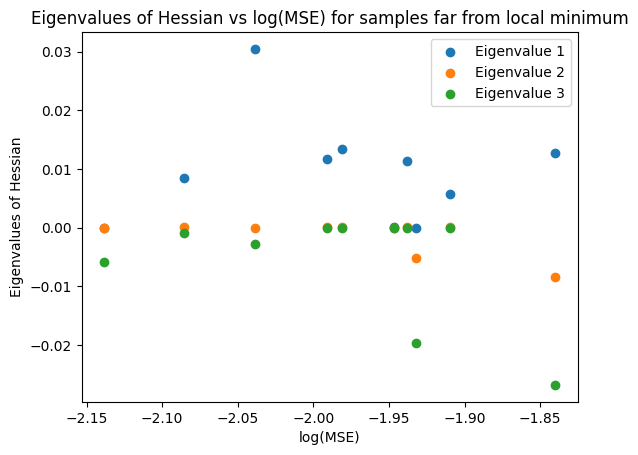

In [4]:
log_mse_arr=[]
eigval_1_arr=[] # largest eigenvalue
eigval_2_arr=[] # second largest eigenvalue
eigval_3_arr=[] # smallest eigenvalue

for sub_sample in res_far:
    current=sub_sample["current"]
    I_dict={"I_1": current[0], "I_3": current[1], "I_10": current[2]}
    
    mse=compute_weighted_MSE(I_dict, A_VARS, A_OBJ)[0]
    log_mse_arr.append(np.log10(mse))
    H=compute_hessian_phi(I_dict, A_VARS, A_OBJ)[0]
    eigvals=compute_eig(H)[0]
    eigvals.sort()
    eigvals = eigvals[::-1]
    eigval_1_arr.append(eigvals[0])
    eigval_2_arr.append(eigvals[1])
    eigval_3_arr.append(eigvals[2])
plt.scatter(log_mse_arr, eigval_1_arr, label='Eigenvalue 1')
plt.scatter(log_mse_arr, eigval_2_arr, label='Eigenvalue 2')
plt.scatter(log_mse_arr, eigval_3_arr, label='Eigenvalue 3')
plt.xlabel('log(MSE)')
plt.ylabel('Eigenvalues of Hessian')
plt.title('Eigenvalues of Hessian vs log(MSE) for samples far from local minimum')
plt.legend()
plt.show()

plot of eigenvector directions of samples close to the local minimum, in scenario , I_1 and I_3 as the current variables, `alpha_x=0 at position 8` and `alpha_y=0 at position 9`

✓ experiment results loaded from ../../results/scenario_A_results.pkl
Grid 500 500, MSE range [9.79e-06, 3.41e+03]


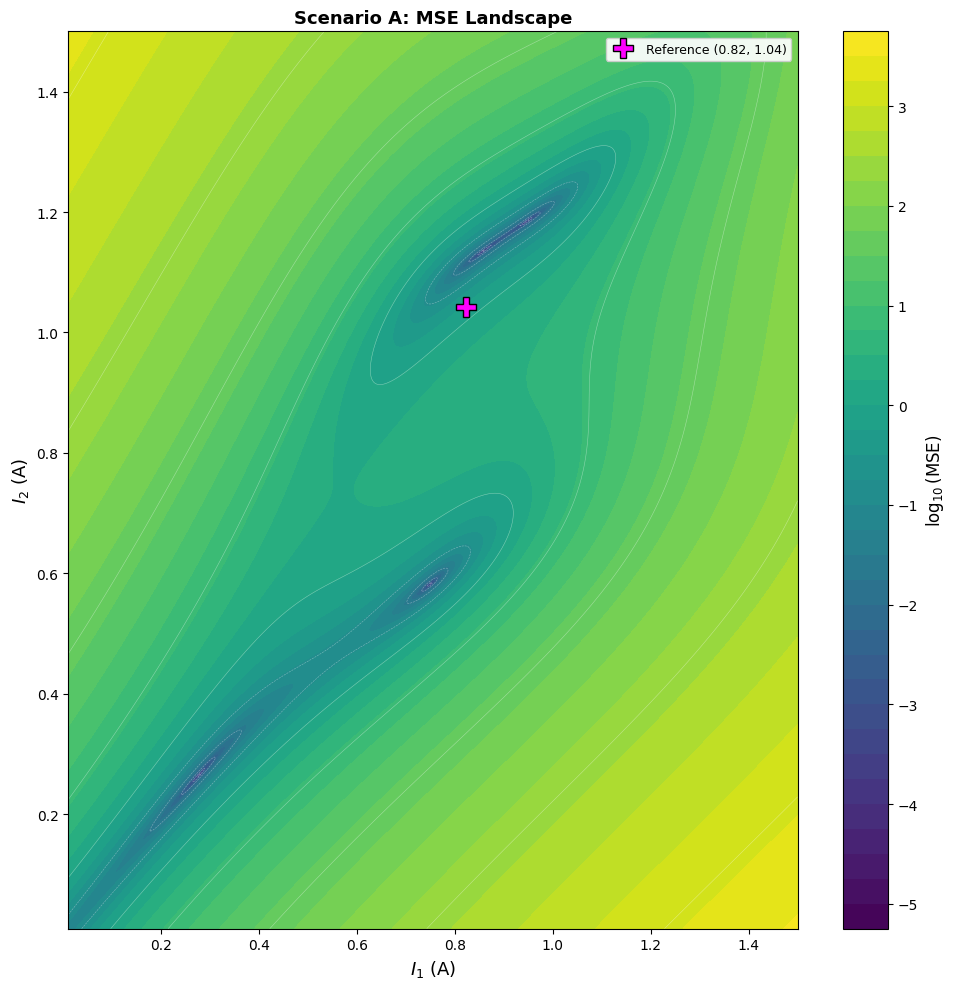

In [36]:
# produce the scan
from experiments_utils import plot_contour, load_results
with open('../../results/scenario_A_landscape.pkl', 'rb') as f: 
    landscape = pickle.load(f)

results_A, df_A, final_summary = load_results('../../results/scenario_A_results.pkl')

plot_contour('../../results/scenario_A_landscape.pkl')    

In [37]:
from SOBOL_scan import get_random_samples, compute_hessian_phi, compute_eig

local_min_1 = {"I_1": 0.7512, "I_3": 0.5806}
local_min_2 = {"I_1": 0.25, "I_3": 0.27}
local_min_3 = {"I_1": 0.85, "I_3": 1.13}
local_min_4 = {"I_1": 0.95, "I_3": 1.19}

local_list = [local_min_1, local_min_2, local_min_3, local_min_4]

A_VARS = {
    1: ["I_1", "current", lambda x: x],
    3: ["I_3", "current", lambda x: x],
}

A_OBJ = {
    8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
}


Grid 500 500, MSE range [9.79e-06, 3.41e+03]
[[-0.7443182   0.66782514]
 [-0.66782514 -0.7443182 ]]
[[-0.82024583  0.57201117]
 [-0.57201117 -0.82024583]]
[[-0.70853115  0.70567947]
 [-0.70567954 -0.70853122]]
[[-0.81895573  0.5738567 ]
 [-0.5738567  -0.81895573]]
[[ 0.85063594  0.52575516]
 [-0.52575516  0.85063594]]
[[-0.79672221  0.60434577]
 [-0.60434569 -0.79672215]]
[[-0.8233067   0.56759676]
 [-0.56759676 -0.8233067 ]]
[[-0.95653797  0.29160767]
 [-0.29160781 -0.95653801]]
[[-0.82284503  0.56826572]
 [-0.56826583 -0.82284511]]
[[-0.83323901  0.55291289]
 [-0.55291297 -0.83323907]]
[[ 0.92650456  0.37628355]
 [-0.37628355  0.92650455]]
[[-0.94364583  0.33095701]
 [-0.33095702 -0.94364583]]
[[ 0.91421721  0.4052245 ]
 [-0.4052245   0.91421721]]
[[ 0.97814239  0.20793619]
 [-0.20793619  0.97814239]]
[[ 0.94465398  0.32806839]
 [-0.32806838  0.94465397]]
[[ 0.96559389  0.26005467]
 [-0.26005467  0.96559389]]
[[ 0.70716893  0.70704462]
 [-0.70704463  0.70716893]]
[[ 0.92778222  0.373

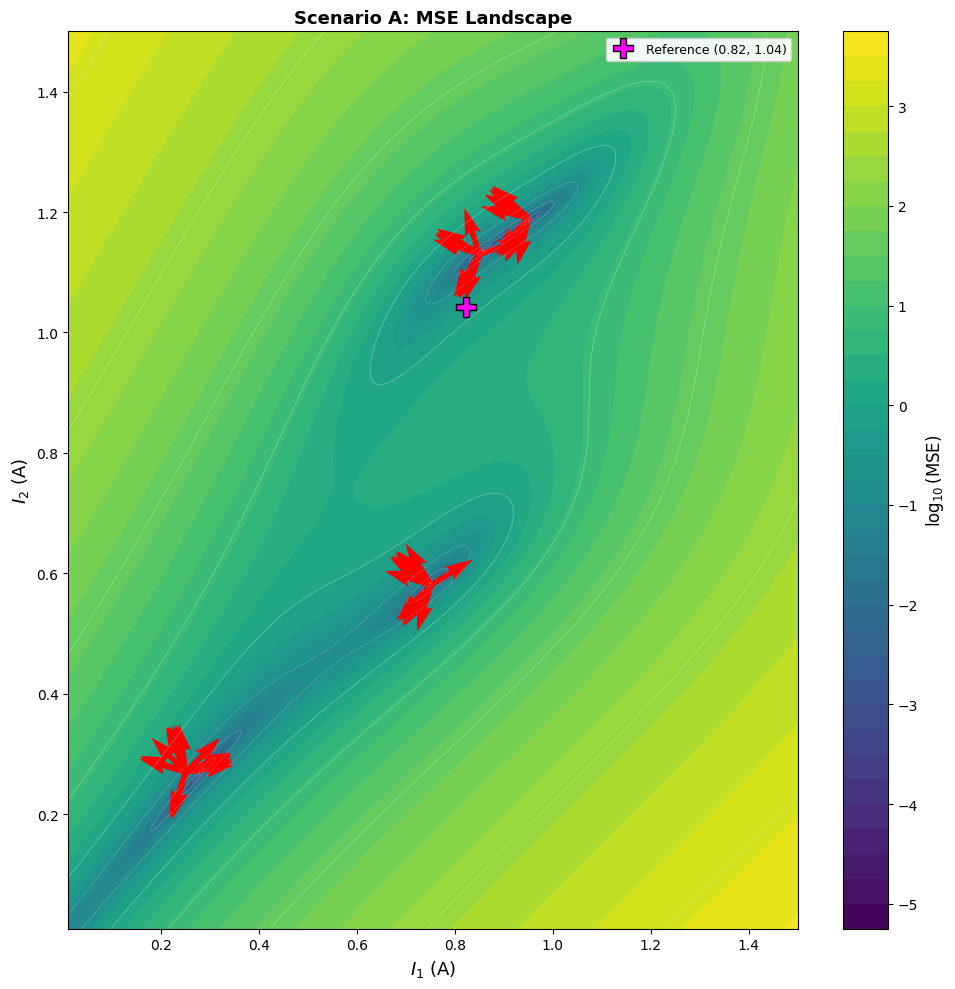

In [ ]:
# plot_contour('../../results/scenario_A_landscape.pkl')  
path='../../results/scenario_A_landscape.pkl'
with open(path, "rb") as f:
    L = pickle.load(f)
    I1_vals, I2_vals, MSE_grid = L["I1_vals"], L["I2_vals"], L["MSE_grid"]

    print(f"Grid {L['N_GRID']} {L['N_GRID']}, MSE range [{np.nanmin(MSE_grid):.2e}, {np.nanmax(MSE_grid):.2e}]")

    Z = np.log10(np.maximum(MSE_grid, 1e-16))

    fig, ax = plt.subplots(figsize=(10, 10))

    cf = ax.contourf(I1_vals, I2_vals, Z, levels=40, cmap='viridis')
    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label(r'$\log_{10}(\mathrm{MSE})$', fontsize=12)

    ax.contour(I1_vals, I2_vals, Z, levels=12, colors='white', linewidths=0.4, alpha=0.4)

    ax.plot(0.8218, 1.0430, 'P', color='magenta', markersize=15,
            markeredgecolor='black', label='Reference (0.82, 1.04)', zorder=11)

    ax.set_xlabel(r'$I_1$ (A)', fontsize=13)
    ax.set_ylabel(r'$I_2$ (A)', fontsize=13)
    ax.set_title('Scenario A: MSE Landscape', fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right', framealpha=0.92)
    ax.set_xlim(I1_vals[0], I1_vals[-1])
    ax.set_ylim(I2_vals[0], I2_vals[-1])
    fig.tight_layout()
    # plt.show()


for local_min in local_list:
    bounds = np.array([0, 1.5])
    num_samples = 10
    thres_1 = 0.01
    thres_2 = 0.5
    mode = "close"
    samples = get_random_samples(local_min, bounds, num_samples, thres_1, thres_2, mode)
    for sample in samples:
        H=compute_hessian_phi(sample, A_VARS, A_OBJ)[0]
        eigval=compute_eig(H)[0]
        eigvec=compute_eig(H)[1]
        for eig_vec in eigvec:
            plt.quiver(local_min["I_1"], local_min["I_3"], eig_vec[0], eig_vec[1], color='r', scale=15)
        
plt.show()